In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import os
import sqlite3

In [2]:
conn = sqlite3.connect('healthcare.db')

In [3]:
for file in os.listdir('dataset'):
    if file.endswith('.csv'):
        df = pd.read_csv(f'dataset/{file}')
        df.to_sql('healthcare',conn, if_exists="replace",index=False)
        print(file)

healthcare_dataset.csv


In [5]:
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [131]:
df.isnull().sum()

Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

In [43]:
df.describe()

,Age,Billing Amount,Room Number
count,55500.000000,55500.000000,55500.000000
mean,51.539459,25539.316097,301.134829
std,19.602454,14211.454431,115.243069
min,13.000000,-2008.492140,101.000000
25%,35.000000,13241.224652,202.000000
50%,52.000000,25538.069376,302.000000
75%,68.000000,37820.508436,401.000000
max,89.000000,52764.276736,500.000000


In [133]:
pd.read_sql_query("""select * from healthcare where "Billing Amount" < 0;""",conn)

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,ashLEy ERIcKSoN,32,Female,AB-,Cancer,2019-11-05,Gerald Hooper,"and Johnson Moore, Branch",Aetna,-502.507813,376,Urgent,2019-11-23,Penicillin,Normal
1,CHRisTOPHer wEiss,49,Female,AB-,Asthma,2023-02-16,Kelly Thompson,Hunter-Hughes,Aetna,-1018.245371,204,Elective,2023-03-09,Penicillin,Inconclusive
2,AsHley WaRnER,60,Male,A+,Hypertension,2021-12-21,Andrea Bentley,"and Wagner, Lee Klein",Aetna,-306.364925,426,Elective,2022-01-11,Ibuprofen,Normal
3,JAY galloWaY,74,Female,O+,Asthma,2021-01-20,Debra Everett,Group Peters,Blue Cross,-109.097122,381,Emergency,2021-02-09,Ibuprofen,Abnormal
4,josHUa wilLIamSon,72,Female,B-,Diabetes,2021-03-21,Wendy Ramos,"and Huff Reeves, Dennis",Blue Cross,-576.727907,369,Urgent,2021-04-17,Aspirin,Abnormal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,JosEPh cOx,23,Male,AB-,Diabetes,2019-10-13,Peter Smith,Inc Ward,Blue Cross,-353.865186,271,Elective,2019-10-25,Lipitor,Inconclusive
104,AsHley WaRnER,55,Male,A+,Hypertension,2021-12-21,Andrea Bentley,"and Wagner, Lee Klein",Aetna,-306.364925,426,Elective,2022-01-11,Ibuprofen,Normal
105,dAnIel dRaKe,68,Female,B+,Hypertension,2020-04-24,Brett Ray,Carr Ltd,Aetna,-591.917419,426,Elective,2020-04-26,Lipitor,Abnormal
106,DR. micHaEl MckAy,64,Male,O+,Cancer,2019-05-31,Dawn Navarro,"Mcconnell and Rios, Clark",UnitedHealthcare,-199.663795,122,Urgent,2019-06-12,Ibuprofen,Abnormal


In [111]:
df[df["Billing Amount"]<0]["Insurance Provider"].value_counts()

Insurance Provider
Aetna               27
Cigna               24
Medicare            22
UnitedHealthcare    19
Blue Cross          16
Name: count, dtype: int64

In [105]:
df[df["Billing Amount"]<0]["Medical Condition"].value_counts()

Medical Condition
Hypertension    21
Diabetes        20
Cancer          19
Obesity         19
Asthma          18
Arthritis       11
Name: count, dtype: int64

In [106]:
df[df["Billing Amount"]<0]["Admission Type"].value_counts()

Admission Type
Urgent       38
Elective     37
Emergency    33
Name: count, dtype: int64

In [134]:
df["Billing Amount"] = df["Billing Amount"].abs()

In [135]:
df.to_sql('healthcare',conn,if_exists='replace',index=False)

55500

In [136]:
df.describe()

,Age,Billing Amount,Room Number
count,55500.000000,55500.000000,55500.000000
mean,51.539459,25541.259324,301.134829
std,19.602454,14207.961646,115.243069
min,13.000000,9.238787,101.000000
25%,35.000000,13241.224652,202.000000
50%,52.000000,25538.069376,302.000000
75%,68.000000,37820.508436,401.000000
max,89.000000,52764.276736,500.000000


In [137]:
pd.read_sql_query("""select * from healthcare;""",conn)

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55495,eLIZABeTH jaCkSOn,42,Female,O+,Asthma,2020-08-16,Joshua Jarvis,Jones-Thompson,Blue Cross,2650.714952,417,Elective,2020-09-15,Penicillin,Abnormal
55496,KYle pEREz,61,Female,AB-,Obesity,2020-01-23,Taylor Sullivan,Tucker-Moyer,Cigna,31457.797307,316,Elective,2020-02-01,Aspirin,Normal
55497,HEATher WaNG,38,Female,B+,Hypertension,2020-07-13,Joe Jacobs DVM,"and Mahoney Johnson Vasquez,",UnitedHealthcare,27620.764717,347,Urgent,2020-08-10,Ibuprofen,Abnormal
55498,JENniFER JOneS,43,Male,O-,Arthritis,2019-05-25,Kimberly Curry,"Jackson Todd and Castro,",Medicare,32451.092358,321,Elective,2019-05-31,Ibuprofen,Abnormal


In [138]:
df['Name'] = df['Name'].str.title()

In [140]:
df.to_sql('healthcare',conn,if_exists='replace',index=False)

55500

In [50]:
pd.read_sql_query("""select Name, Gender,
"Blood Type", Age,
"Medical Condition",
"Date of Admission", "Discharge Date",
"Admission type", "Test Results",
julianday("Discharge Date") - julianday("Date of Admission") as staying_duration from healthcare where Age < 18;""",conn)

,Name,Gender,Blood Type,Age,Medical Condition,Date of Admission,Discharge Date,Admission Type,Test Results,staying_duration
0,jOSePH mcDOnald,Male,AB+,17,Diabetes,2023-01-12,2023-02-10,Emergency,Inconclusive,29.0
1,AngELa SANtOS,Male,B-,15,Asthma,2019-06-06,2019-07-01,Emergency,Abnormal,25.0
2,alExAndeR SHannON,Male,A-,16,Hypertension,2023-03-31,2023-04-23,Emergency,Normal,23.0
3,natashA SMITh,Female,A+,15,Diabetes,2020-07-23,2020-08-09,Elective,Abnormal,17.0
4,miCHAEL wILlIAMs,Female,B-,17,Hypertension,2023-01-10,2023-01-29,Emergency,Inconclusive,19.0
...,...,...,...,...,...,...,...,...,...,...
111,jIm DAY,Male,O-,14,Arthritis,2021-06-20,2021-06-28,Elective,Abnormal,8.0
112,JosEpH RodRIgueZ,Male,B-,17,Arthritis,2023-06-14,2023-07-09,Emergency,Inconclusive,25.0
113,kRiStiN orTIZ,Male,A-,13,Asthma,2020-04-01,2020-04-02,Urgent,Abnormal,1.0
114,DEBRa MIller,Male,AB-,17,Cancer,2021-07-29,2021-08-01,Urgent,Abnormal,3.0


In [69]:
pd.read_sql_query("""select count(*) as total_patient, Gender, "Medical Condition", ROUND(AVG(Age),2) as average_Age,
ROUND(AVG(julianday("Discharge Date") - julianday("Date of Admission")),2) as avg_staying_duration
from healthcare where Age < 18 group by Gender, "Medical Condition" order by total_patient Desc;""",conn)


,total_patient,Gender,Medical Condition,average_Age,avg_staying_duration
0,15,Female,Obesity,15.13,13.07
1,13,Male,Cancer,15.69,6.92
2,12,Male,Obesity,14.58,16.58
3,11,Male,Arthritis,15.64,16.00
4,10,Female,Arthritis,15.80,15.80
5,10,Female,Asthma,15.10,18.40
6,10,Male,Asthma,14.90,16.40
7,9,Male,Diabetes,15.89,18.89
8,8,Female,Cancer,15.50,18.50
9,7,Female,Diabetes,15.29,20.86


In [141]:
pd.read_sql_query("""select Name, Gender,
Age, "Blood Type",
"Date of Admission", "Discharge Date",
julianday("Discharge Date") - julianday("Date of Admission") as Staying_duration,
"Medical Condition", "Admission Type",
"Test Results" from healthcare where Age  BETWEEN '18' AND '59';""",conn) 

,Name,Gender,Age,Blood Type,Date of Admission,Discharge Date,Staying_duration,Medical Condition,Admission Type,Test Results
0,Bobby Jackson,Male,30,B-,2024-01-31,2024-02-02,2.0,Cancer,Urgent,Normal
1,Andrew Watts,Female,28,O+,2020-11-18,2020-12-18,30.0,Diabetes,Elective,Abnormal
2,Adrienne Bell,Female,43,AB+,2022-09-19,2022-10-09,20.0,Cancer,Urgent,Abnormal
3,Emily Johnson,Male,36,A+,2023-12-20,2023-12-24,4.0,Asthma,Urgent,Normal
4,Edward Edwards,Female,21,AB-,2020-11-03,2020-11-15,12.0,Diabetes,Emergency,Inconclusive
...,...,...,...,...,...,...,...,...,...,...
34231,Gloria Bowen,Female,57,B-,2022-07-23,2022-08-18,26.0,Arthritis,Emergency,Abnormal
34232,Elizabeth Jackson,Female,42,O+,2020-08-16,2020-09-15,30.0,Asthma,Elective,Abnormal
34233,Heather Wang,Female,38,B+,2020-07-13,2020-08-10,28.0,Hypertension,Urgent,Abnormal
34234,Jennifer Jones,Male,43,O-,2019-05-25,2019-05-31,6.0,Arthritis,Elective,Abnormal


In [143]:
pd.read_sql_query("""select count(*) as total_patitent, AVG(Age) as avg_age, Gender, "Medical Condition",
ROUND(AVG(julianday("Discharge Date") - julianday("Date of Admission")),2) as Avg_staying_duration from healthcare 
where Age BETWEEN '18' and '59' group by Gender,"Medical Condition" order by total_patitent Desc;""",conn)

,total_patitent,avg_age,Gender,Medical Condition,Avg_staying_duration
0,2903,38.599035,Female,Arthritis,15.49
1,2897,38.870556,Male,Hypertension,15.58
2,2887,38.915483,Female,Obesity,15.42
3,2876,38.610570,Male,Obesity,15.28
4,2868,38.951534,Male,Diabetes,15.43
5,2865,38.717277,Female,Diabetes,15.30
6,2862,38.968903,Male,Arthritis,15.43
7,2852,38.550842,Female,Cancer,15.54
8,2849,38.563356,Male,Asthma,15.78
9,2818,38.700852,Male,Cancer,15.27


In [144]:
pd.read_sql_query("""select Name, Gender, Age, 
"Blood Type", "Date of Admission", "Discharge Date",
julianday("Discharge Date") - julianday("Date of Admission") as Staying_duration, "Medical Condition",
"Admission Type", "Test Results" from healthcare where Age BETWEEN '60' and '90';""",conn)

,Name,Gender,Age,Blood Type,Date of Admission,Discharge Date,Staying_duration,Medical Condition,Admission Type,Test Results
0,Leslie Terry,Male,62,A+,2019-08-20,2019-08-26,6.0,Obesity,Emergency,Inconclusive
1,Danny Smith,Female,76,A-,2022-09-22,2022-10-07,15.0,Obesity,Emergency,Normal
2,Jasmine Aguilar,Male,82,AB+,2020-07-01,2020-07-14,13.0,Asthma,Elective,Abnormal
3,Michelle Daniels,Male,72,O+,2020-04-19,2020-04-22,3.0,Cancer,Urgent,Normal
4,Connor Hansen,Female,75,A+,2019-12-12,2019-12-28,16.0,Diabetes,Emergency,Abnormal
...,...,...,...,...,...,...,...,...,...,...
21143,Misty Richards,Female,78,O-,2024-04-10,2024-04-23,13.0,Hypertension,Emergency,Normal
21144,Andrew Aguilar,Male,69,O-,2019-06-25,2019-07-09,14.0,Arthritis,Urgent,Normal
21145,Stephanie Oliver,Male,82,B-,2022-01-10,2022-01-21,11.0,Cancer,Emergency,Abnormal
21146,Jessica White,Male,67,O+,2023-12-11,2024-01-04,24.0,Arthritis,Emergency,Normal


In [145]:
pd.read_sql_query("""select count(*) as total_patient, "Medical Condition", AVG(Age) as Average_age,
Gender, ROUND(AVG(julianday("Discharge Date") - julianday("Date of Admission")),2) as Avg_staying_duration
from healthcare where Age BETWEEN '60' and '90' group by "Medical Condition",Gender order by total_patient Desc;""",conn)

,total_patient,Medical Condition,Average_age,Gender,Avg_staying_duration
0,1825,Hypertension,72.892603,Female,15.35
1,1794,Cancer,72.584727,Male,15.58
2,1779,Diabetes,72.409219,Female,15.47
3,1776,Diabetes,72.047297,Male,15.53
4,1773,Arthritis,72.606881,Female,15.35
5,1773,Asthma,72.487310,Male,15.77
6,1766,Asthma,72.725934,Female,15.55
7,1749,Arthritis,72.799314,Male,15.87
8,1742,Cancer,72.435132,Female,15.75
9,1730,Hypertension,72.343353,Male,15.51


# Medication Analysis

In [6]:
pd.read_sql_query("""select count(*) as patitent_count,
Medication,	"Medical Condition",
"Admission Type" from healthcare group by Medication, "Medical Condition", "Admission Type" order by patitent_count Desc;""",conn)

,patitent_count,Medication,Medical Condition,Admission Type
0,680,Penicillin,Diabetes,Urgent
1,677,Paracetamol,Cancer,Elective
2,676,Aspirin,Diabetes,Urgent
3,675,Ibuprofen,Cancer,Elective
4,667,Aspirin,Arthritis,Elective
...,...,...,...,...
85,572,Ibuprofen,Arthritis,Elective
86,565,Ibuprofen,Cancer,Emergency
87,564,Paracetamol,Cancer,Emergency
88,555,Aspirin,Asthma,Emergency


# Hospital Analysis

In [7]:
pd.set_option('display.float_format', '{:,.2f}'.format)

In [8]:
pd.read_sql_query("""select count(*) as patitent_count, "Medical Condition", AVG("Billing Amount") as average_billing,
SUM("Billing Amount") as total_billing_amount, "Admission Type",
"Insurance Provider" from healthcare group by "Medical Condition" order by patitent_count Desc ;""",conn)


,patitent_count,Medical Condition,average_billing,total_billing_amount,Admission Type,Insurance Provider
0,9308,Arthritis,"25,497.33","237,329,120.23",Elective,UnitedHealthcare
1,9304,Diabetes,"25,638.41","238,539,725.49",Elective,Medicare
2,9245,Hypertension,"25,497.10","235,720,650.31",Urgent,Medicare
3,9231,Obesity,"25,805.97","238,214,920.69",Emergency,Medicare
4,9227,Cancer,"25,161.79","232,167,861.31",Urgent,Blue Cross
5,9185,Asthma,"25,635.25","235,459,765.36",Urgent,UnitedHealthcare


In [5]:
df

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55495,eLIZABeTH jaCkSOn,42,Female,O+,Asthma,2020-08-16,Joshua Jarvis,Jones-Thompson,Blue Cross,2650.714952,417,Elective,2020-09-15,Penicillin,Abnormal
55496,KYle pEREz,61,Female,AB-,Obesity,2020-01-23,Taylor Sullivan,Tucker-Moyer,Cigna,31457.797307,316,Elective,2020-02-01,Aspirin,Normal
55497,HEATher WaNG,38,Female,B+,Hypertension,2020-07-13,Joe Jacobs DVM,"and Mahoney Johnson Vasquez,",UnitedHealthcare,27620.764717,347,Urgent,2020-08-10,Ibuprofen,Abnormal
55498,JENniFER JOneS,43,Male,O-,Arthritis,2019-05-25,Kimberly Curry,"Jackson Todd and Castro,",Medicare,32451.092358,321,Elective,2019-05-31,Ibuprofen,Abnormal


# Exploratory Data Analysis

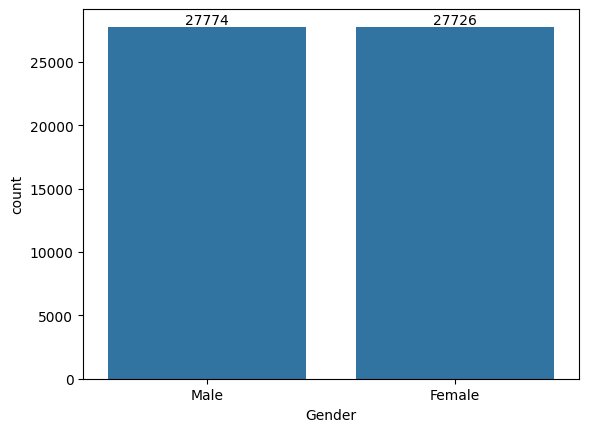

In [11]:
ax = sns.countplot(data = df ,x = 'Gender')
for bars in ax.containers:
    ax.bar_label(bars)


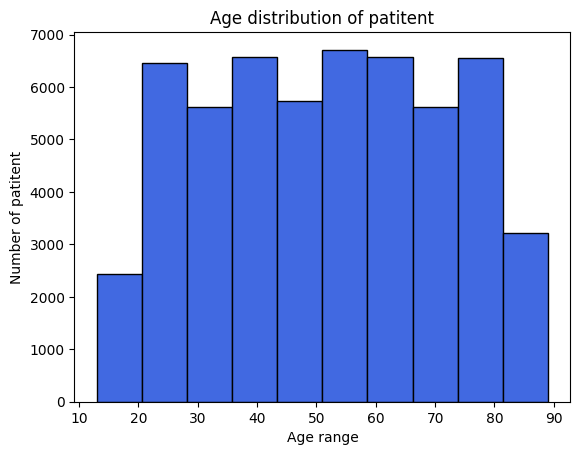

In [10]:
plt.hist(df["Age"],bins = 10,color = 'royalblue',edgecolor = 'black')
plt.xlabel('Age range')
plt.ylabel('Number of patitent')
plt.title('Age distribution of patitent')
plt.show()


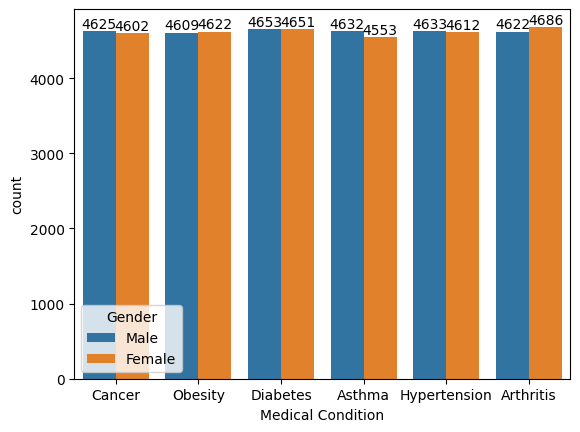

In [27]:
ax = sns.countplot(data = df,x = 'Medical Condition',hue = 'Gender')
for bars in ax.containers:
    ax.bar_label(bars)
    

In [ ]:
Blood Type, Admission Type, Insurance Provider → countplots

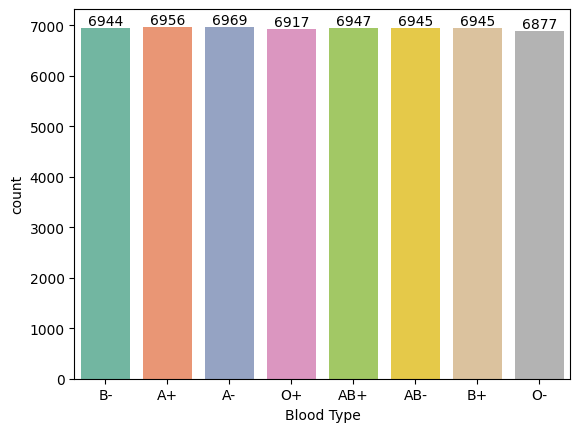

In [42]:
ax = sns.countplot(x = 'Blood Type',data = df, palette = 'Set2', hue = 'Blood Type')
for bars in ax.containers:
    ax.bar_label(bars)

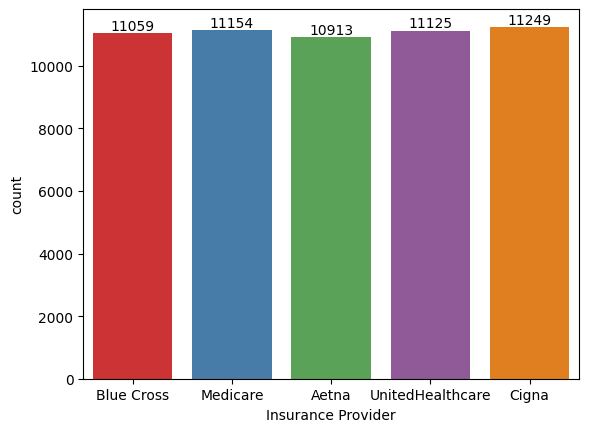

In [47]:
ax = sns.countplot(x = 'Insurance Provider',data = df,palette = 'Set1', hue = 'Insurance Provider')
for bars in ax.containers:
    ax.bar_label(bars)

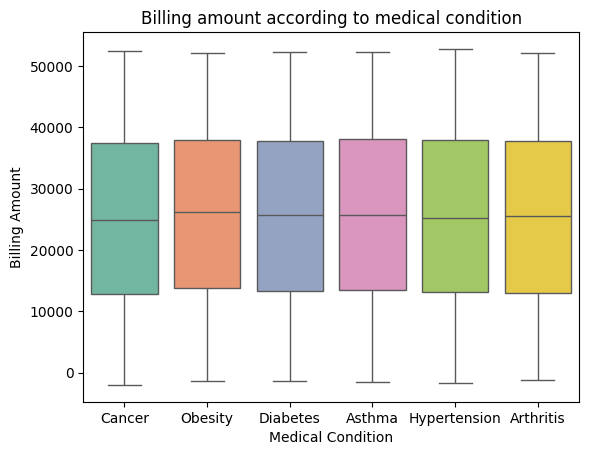

In [39]:
sns.boxplot(data = df, x = 'Medical Condition', y = 'Billing Amount',palette = 'Set2',hue = 'Medical Condition')
plt.title('Billing amount according to medical condition')
plt.show()


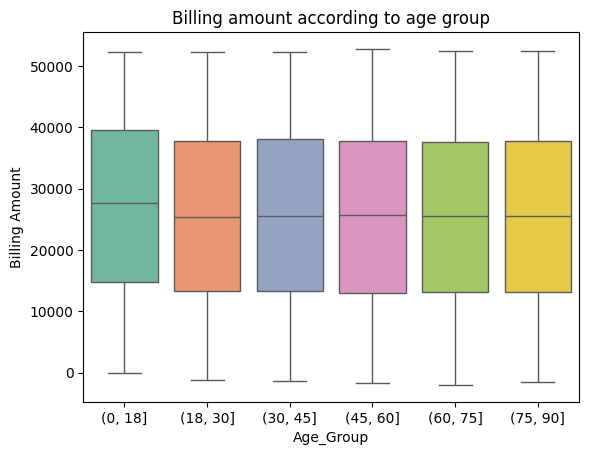

In [4]:
df['Age_Group'] = pd.cut(df['Age'], bins=[0,18,30,45,60,75,90])
plt.title('Billing amount according to age group')
sns.boxplot(data=df, x='Age_Group', y='Billing Amount',palette = 'Set2',hue = 'Age_Group',legend=False)
plt.show()

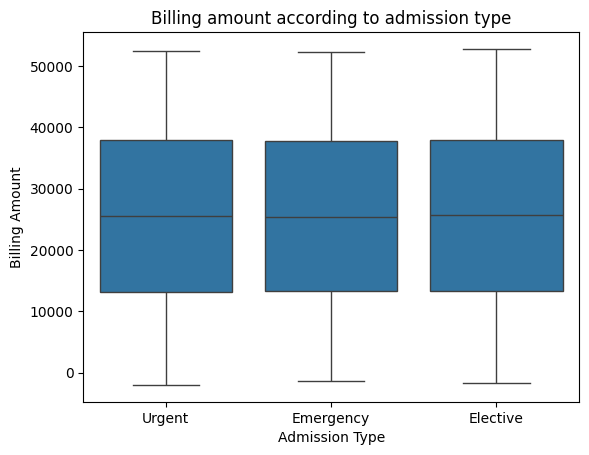

In [81]:
ax = sns.boxplot(x = 'Admission Type', y = 'Billing Amount', data = df)
plt.title('Billing amount according to admission type')
plt.show()

## 

In [ ]:
ax = sns.countplot(x = 